## Assignment 2 - DLP
#### Layyana Junaid 23k0056

In [1]:
!pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [12]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
transform = transforms.ToTensor()

train_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [03:06<00:00, 913kB/s]  
C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

In [4]:
##extracting the horse image
horse_train = []
horse_test = []

for img, label in train_dataset:
    if label == 7:
        horse_train.append(img)

for img, label in test_dataset:
    if label == 7:
        horse_test.append(img)

print("Train horse images:", len(horse_train))
print("Test horse images:", len(horse_test))

Train horse images: 5000
Test horse images: 1000


### Displaying the Colourized Images

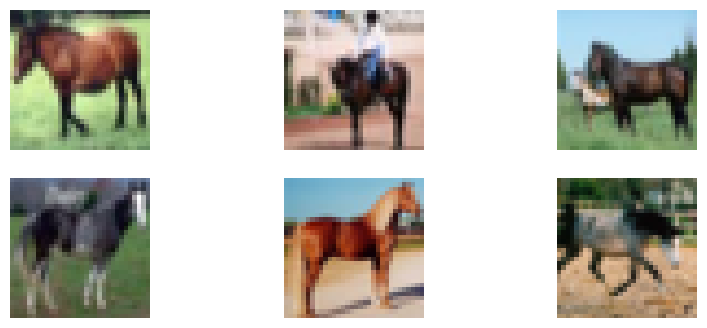

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(horse_train[i].permute(1,2,0))
    plt.axis("off")

plt.show()

### Converting them to Grayscale

In [6]:
##converting to grayscale
def rgb_to_gray(img):
    r,g,b = img[0],img[1],img[2]
    gray = 0.299*r + 0.587*g + 0.114*b
    return gray.unsqueeze(0)

Text(0.5, 1.0, 'Grayscale')

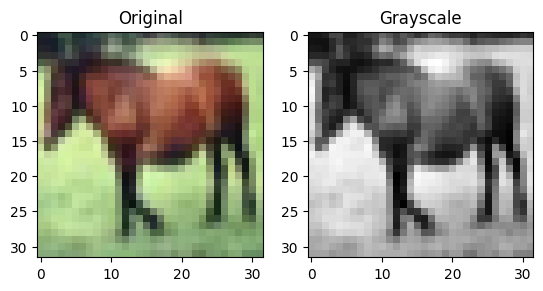

In [7]:
gray = rgb_to_gray(horse_train[0])

plt.subplot(1,2,1)
plt.imshow(horse_train[0].permute(1,2,0))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(gray.squeeze(), cmap="gray")
plt.title("Grayscale")

In [8]:
##creating a custom dataset
from torch.utils.data import Dataset

class HorseDataset(Dataset):

    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        rgb = self.images[idx]
        gray = rgb_to_gray(rgb)

        return gray, rgb

In [9]:
##batch size 100 alr mentioned in assignment
from torch.utils.data import DataLoader

train_data = HorseDataset(horse_train)
test_data = HorseDataset(horse_test)

train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
test_loader = DataLoader(test_data, batch_size=100)

### Regression CNN

In [13]:
import torch.nn as nn

class ColorizationCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,64,3,padding=1)
        self.conv2 = nn.Conv2d(64,128,3,padding=1)
        self.conv3 = nn.Conv2d(128,128,3,padding=1)
        self.conv4 = nn.Conv2d(128,64,3,padding=1)
        self.conv5 = nn.Conv2d(64,3,3,padding=1)

    def forward(self,x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))

        x = torch.sigmoid(self.conv5(x))

        return x

In [14]:
##creating model
model = ColorizationCNN()

##training set up
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
##training loop -> epochs 
epochs = 20

for epoch in range(epochs):

    total_loss = 0

    for gray,rgb in train_loader:

        pred = model(gray)

        loss = criterion(pred, rgb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 0.019434949923306702
Epoch: 1 Loss: 0.006659936876967549
Epoch: 2 Loss: 0.0052265656180679795
Epoch: 3 Loss: 0.00465554567053914
Epoch: 4 Loss: 0.004462769785895944
Epoch: 5 Loss: 0.004355229730717838
Epoch: 6 Loss: 0.0043637534510344266
Epoch: 7 Loss: 0.004223897960036993
Epoch: 8 Loss: 0.004287486029788852
Epoch: 9 Loss: 0.004267590781673789
Epoch: 10 Loss: 0.004222201472148299
Epoch: 11 Loss: 0.004191916007548571
Epoch: 12 Loss: 0.004152154261246324
Epoch: 13 Loss: 0.004120930409990251
Epoch: 14 Loss: 0.004117412529885769
Epoch: 15 Loss: 0.004063233616761863
Epoch: 16 Loss: 0.004055894799530506
Epoch: 17 Loss: 0.004070414956659079
Epoch: 18 Loss: 0.0040781913604587315
Epoch: 19 Loss: 0.004074951205402613


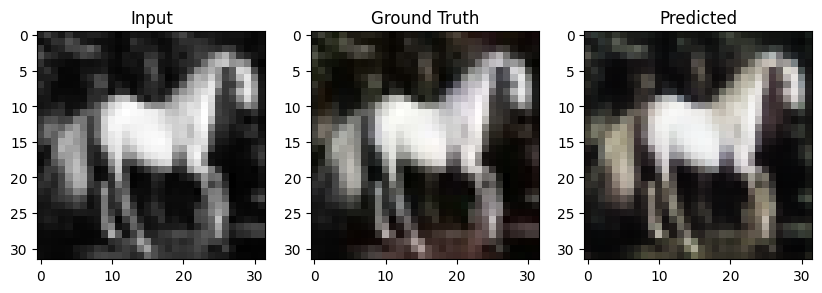

In [17]:
gray,rgb = next(iter(test_loader))

pred = model(gray)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(gray[0].squeeze(), cmap="gray")
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(rgb[0].permute(1,2,0))
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred[0].detach().permute(1,2,0))
plt.title("Predicted")

plt.show()

In [18]:
from sklearn.cluster import KMeans

pixels = []

for img in horse_train:
    img = img.permute(1,2,0).numpy()   # 32x32x3
    pixels.append(img.reshape(-1,3))   # flatten pixels

pixels = np.concatenate(pixels, axis=0)

print("Total pixels:", pixels.shape)

Total pixels: (5120000, 3)


In [19]:
kmeans = KMeans(n_clusters=24, random_state=42)
kmeans.fit(pixels)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",24
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
color_clusters = kmeans.cluster_centers_

print(color_clusters.shape)
print(color_clusters[:5])

(24, 3)
[[0.6222807  0.6879818  0.3994043 ]
 [0.15932119 0.13692057 0.1155614 ]
 [0.8847346  0.8873837  0.8802998 ]
 [0.30545503 0.29646462 0.2760681 ]
 [0.29981583 0.42838082 0.5417382 ]]


In [21]:
np.save("colour_kmeans24_cat7.npy", color_clusters)

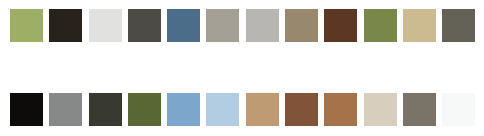

In [22]:
colors = np.load("colour_kmeans24_cat7.npy")

plt.figure(figsize=(6,2))

for i,c in enumerate(color_clusters):
    plt.subplot(2,12,i+1)
    plt.imshow([[c]])
    plt.axis("off")

plt.show()

In [23]:
colors = torch.tensor(colors, dtype=torch.float32)

def rgb_to_class_map(rgb_img, centers):
    """
    rgb_img: torch tensor of shape [3, 32, 32]
    centers: torch tensor of shape [24, 3]
    returns: torch tensor of shape [32, 32] with values 0..23
    """
    h, w = rgb_img.shape[1], rgb_img.shape[2]

    # [3, H, W] -> [H*W, 3]
    pixels = rgb_img.permute(1, 2, 0).reshape(-1, 3)

    # compute distances from each pixel to each cluster center
    dists = torch.cdist(pixels.unsqueeze(0), centers.unsqueeze(0)).squeeze(0)  # [H*W, 24]

    labels = torch.argmin(dists, dim=1)  # [H*W]
    labels = labels.reshape(h, w)        # [H, W]

    return labels.long()

In [24]:
sample_rgb = horse_train[0]
sample_labels = rgb_to_class_map(sample_rgb, colors)

print(sample_labels.shape)
print(sample_labels.min(), sample_labels.max())

torch.Size([32, 32])
tensor(0) tensor(22)


In [25]:
class HorseClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, images, centers):
        self.images = images
        self.centers = centers

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        rgb = self.images[idx]                  # [3,32,32]
        gray = rgb_to_gray(rgb)                 # [1,32,32]
        label_map = rgb_to_class_map(rgb, self.centers)  # [32,32]

        return gray, label_map, rgb

In [26]:
cls_train_data = HorseClassificationDataset(horse_train, colors)
cls_test_data = HorseClassificationDataset(horse_test, colors)

cls_train_loader = DataLoader(cls_train_data, batch_size=100, shuffle=True)
cls_test_loader = DataLoader(cls_test_data, batch_size=100, shuffle=False)

In [27]:
gray, labels, rgb = next(iter(cls_train_loader))

print("Gray shape:", gray.shape)      # [B,1,32,32]
print("Labels shape:", labels.shape)  # [B,32,32]
print("RGB shape:", rgb.shape)        # [B,3,32,32]

Gray shape: torch.Size([100, 1, 32, 32])
Labels shape: torch.Size([100, 32, 32])
RGB shape: torch.Size([100, 3, 32, 32])


In [29]:
class MyConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=True):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels, kernel_size, kernel_size) * 0.02
        )

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.bias = None

    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape

        # unfold input into sliding local blocks
        x_unf = F.unfold(
            x,
            kernel_size=self.kernel_size,
            padding=self.padding,
            stride=self.stride
        )  # [B, C*k*k, L]

        # flatten filters
        w = self.weight.view(self.out_channels, -1)  # [out_channels, C*k*k]

        # matrix multiply
        out = torch.matmul(w.unsqueeze(0), x_unf)   # [B, out_channels, L]

        if self.bias is not None:
            out = out + self.bias.view(1, -1, 1)

        out_h = (H + 2*self.padding - self.kernel_size) // self.stride + 1
        out_w = (W + 2*self.padding - self.kernel_size) // self.stride + 1

        out = out.view(B, self.out_channels, out_h, out_w)
        return out

In [30]:
test_layer = MyConv2d(1, 8, kernel_size=3, padding=1)
x = torch.randn(4, 1, 32, 32)
y = test_layer(x)

print(y.shape)

torch.Size([4, 8, 32, 32])


In [31]:
class ClassificationCNN(nn.Module):
    def __init__(self, num_classes=24):
        super().__init__()

        self.conv1 = MyConv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = MyConv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = MyConv2d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = MyConv2d(128, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.conv5 = MyConv2d(64, num_classes, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.conv5(x)   # logits, no softmax here
        return x

In [32]:
cls_model = ClassificationCNN(num_classes=24)
print(cls_model)

ClassificationCNN(
  (conv1): MyConv2d()
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): MyConv2d()
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): MyConv2d()
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): MyConv2d()
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): MyConv2d()
)


In [33]:
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = torch.optim.Adam(cls_model.parameters(), lr=0.001)

In [34]:
def pixel_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)   # [B,32,32]
    correct = (preds == labels).float().sum()
    total = labels.numel()
    return (correct / total).item()

In [35]:
cls_epochs = 20

cls_train_losses = []
cls_train_accs = []

for epoch in range(cls_epochs):
    cls_model.train()
    total_loss = 0
    total_acc = 0

    for gray, labels, _ in cls_train_loader:
        logits = cls_model(gray)                 # [B,24,32,32]
        loss = cls_criterion(logits, labels)     # labels: [B,32,32]

        cls_optimizer.zero_grad()
        loss.backward()
        cls_optimizer.step()

        total_loss += loss.item()
        total_acc += pixel_accuracy(logits, labels)

    avg_loss = total_loss / len(cls_train_loader)
    avg_acc = total_acc / len(cls_train_loader)

    cls_train_losses.append(avg_loss)
    cls_train_accs.append(avg_acc)

    print(f"Epoch: {epoch}  Loss: {avg_loss:.4f}  Pixel Acc: {avg_acc:.4f}")

Epoch: 0  Loss: 1.8723  Pixel Acc: 0.3621
Epoch: 1  Loss: 1.4453  Pixel Acc: 0.4645
Epoch: 2  Loss: 1.3581  Pixel Acc: 0.4868
Epoch: 3  Loss: 1.2851  Pixel Acc: 0.5076
Epoch: 4  Loss: 1.2292  Pixel Acc: 0.5265
Epoch: 5  Loss: 1.2325  Pixel Acc: 0.5204
Epoch: 6  Loss: 1.2054  Pixel Acc: 0.5301
Epoch: 7  Loss: 1.1813  Pixel Acc: 0.5371
Epoch: 8  Loss: 1.1573  Pixel Acc: 0.5470
Epoch: 9  Loss: 1.1340  Pixel Acc: 0.5537
Epoch: 10  Loss: 1.1429  Pixel Acc: 0.5506
Epoch: 11  Loss: 1.1818  Pixel Acc: 0.5350
Epoch: 12  Loss: 1.1296  Pixel Acc: 0.5547
Epoch: 13  Loss: 1.1138  Pixel Acc: 0.5593
Epoch: 14  Loss: 1.1360  Pixel Acc: 0.5500
Epoch: 15  Loss: 1.1100  Pixel Acc: 0.5594
Epoch: 16  Loss: 1.1265  Pixel Acc: 0.5546
Epoch: 17  Loss: 1.1096  Pixel Acc: 0.5595
Epoch: 18  Loss: 1.0976  Pixel Acc: 0.5647
Epoch: 19  Loss: 1.0797  Pixel Acc: 0.5702


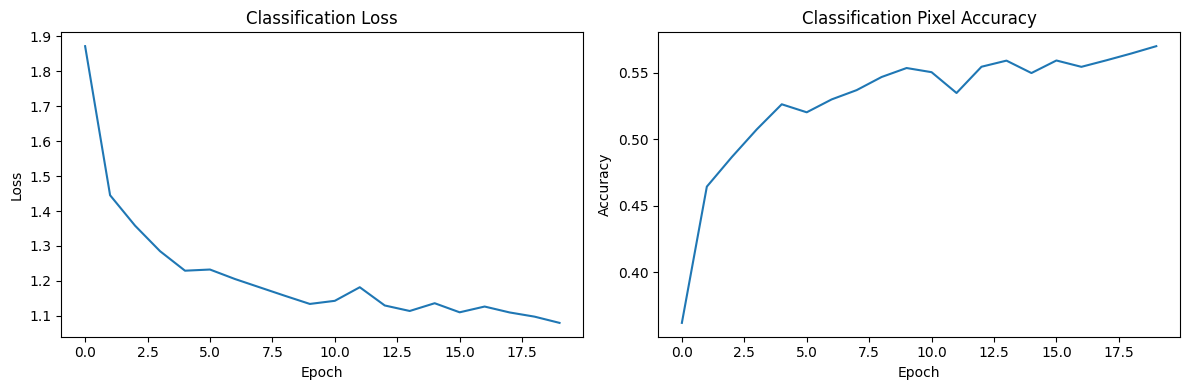

In [36]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(cls_train_losses)
plt.title("Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(cls_train_accs)
plt.title("Classification Pixel Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [37]:
def class_map_to_rgb(class_map, centers):
    """
    class_map: [H, W]
    centers: [24, 3]
    returns: [3, H, W]
    """
    rgb = centers[class_map]  # [H, W, 3]
    rgb = rgb.permute(2, 0, 1)
    return rgb

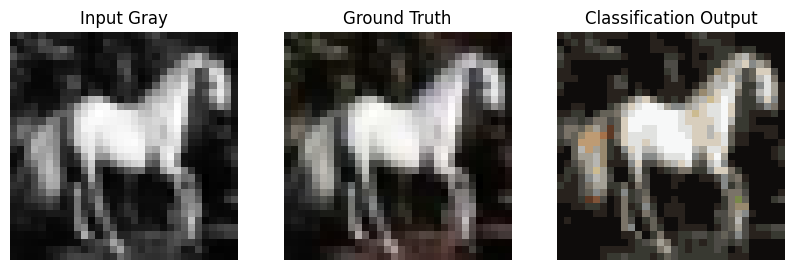

In [38]:
cls_model.eval()

gray, labels, rgb = next(iter(cls_test_loader))

with torch.no_grad():
    logits = cls_model(gray)
    pred_classes = torch.argmax(logits, dim=1)   # [B,32,32]

pred_rgb = class_map_to_rgb(pred_classes[0], colors)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(gray[0].squeeze(), cmap="gray")
plt.title("Input Gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rgb[0].permute(1,2,0))
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_rgb.permute(1,2,0))
plt.title("Classification Output")
plt.axis("off")

plt.show()

In [39]:
model.eval()

gray, rgb = next(iter(test_loader))
x = gray[:1]   # one image

cnn_activations = []

def cnn_hook(module, input, output):
    cnn_activations.append(output)

# Hook first convolution layer
hook = model.conv1.register_forward_hook(cnn_hook)

with torch.no_grad():
    _ = model(x)

hook.remove()

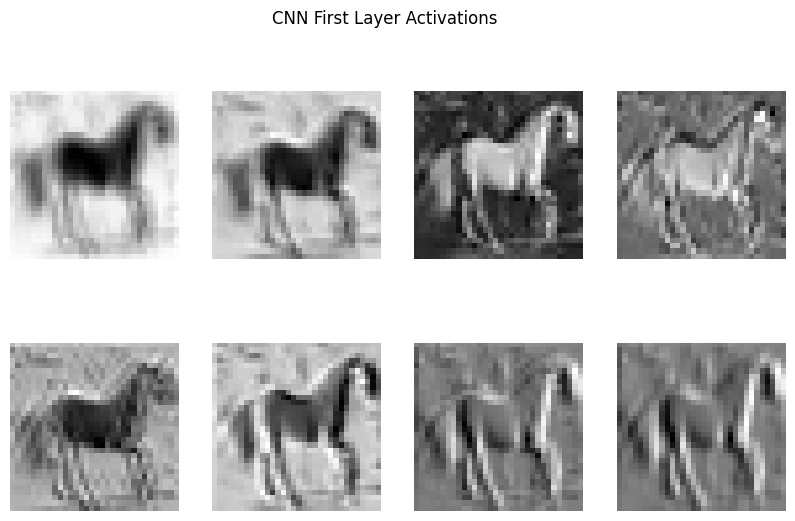

In [40]:
feat = cnn_activations[0][0]

plt.figure(figsize=(10,6))

for i in range(min(8, feat.shape[0])):
    plt.subplot(2,4,i+1)
    plt.imshow(feat[i].cpu(), cmap="gray")
    plt.axis("off")

plt.suptitle("CNN First Layer Activations")
plt.show()

In [44]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class UNetColorization(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, 3, 1)
        self.out_act = nn.Sigmoid()

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.out_conv(d1)
        out = self.out_act(out)

        return out

In [46]:
unet_model = UNetColorization()

unet_criterion = nn.MSELoss()

unet_optimizer = torch.optim.Adam(
    unet_model.parameters(),
    lr=0.001
)

In [47]:
unet_epochs = 20
unet_train_losses = []

for epoch in range(unet_epochs):

    unet_model.train()
    total_loss = 0

    for gray, rgb in train_loader:

        pred = unet_model(gray)
        loss = unet_criterion(pred, rgb)

        unet_optimizer.zero_grad()
        loss.backward()
        unet_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    unet_train_losses.append(avg_loss)

    print("Epoch:", epoch, "Loss:", avg_loss)

Epoch: 0 Loss: 0.019900905471295117
Epoch: 1 Loss: 0.006794844632968307
Epoch: 2 Loss: 0.005125326709821821
Epoch: 3 Loss: 0.004646184081211686
Epoch: 4 Loss: 0.004408429246395827
Epoch: 5 Loss: 0.0042208162182942035
Epoch: 6 Loss: 0.00410965483635664
Epoch: 7 Loss: 0.004071593070402741
Epoch: 8 Loss: 0.003968060361221433
Epoch: 9 Loss: 0.00394127057865262
Epoch: 10 Loss: 0.004002982703968883
Epoch: 11 Loss: 0.003827494545839727
Epoch: 12 Loss: 0.0038093662075698374
Epoch: 13 Loss: 0.003754902360960841
Epoch: 14 Loss: 0.003734619654715061
Epoch: 15 Loss: 0.0037718556961044668
Epoch: 16 Loss: 0.0037080104602500797
Epoch: 17 Loss: 0.0036424603732302784
Epoch: 18 Loss: 0.003610390475951135
Epoch: 19 Loss: 0.0035830493504181503


In [48]:
unet_model.eval()

gray, rgb = next(iter(test_loader))

with torch.no_grad():
    pred = unet_model(gray)

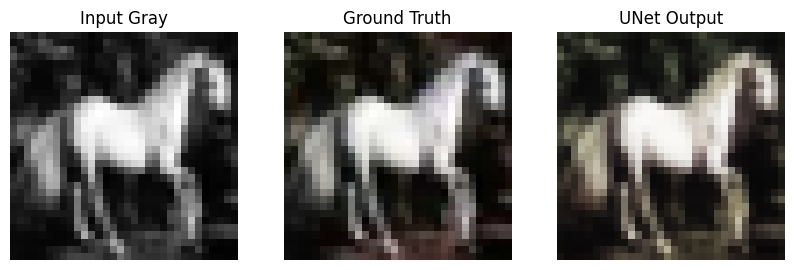

In [49]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(gray[0].squeeze(), cmap="gray")
plt.title("Input Gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rgb[0].permute(1,2,0))
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred[0].permute(1,2,0))
plt.title("UNet Output")
plt.axis("off")

plt.show()